<div style="border-bottom: 4px solid #B85300; padding-bottom: 12px; margin-bottom: 8px;">
<h1 style="font-family: 'Palatino Linotype', Palatino, serif; color: #B85300; margin-bottom:4px;">Hind Oil Industries (HOI) — Aceite Maa</h1>
<p style="font-family: 'Palatino Linotype', Palatino, serif; font-size: 15px; color:#333; margin-top:0;">
EDA · Clustering (DBSCAN) · Regresión log-log &nbsp;|&nbsp; Serie mensual abr-2011 – sep-2015 &nbsp;|&nbsp; Caso Ivey W17230
</p>
</div>

<p style="font-family:'Palatino Linotype', Palatino, serif; font-size:14px;">
<b>Contexto:</b> en septiembre de 2015, Abhishek Khemka (HOI) debe decidir si sube el precio del aceite de mostaza Maa
tras un shock en el costo de la semilla de mostaza, sabiendo que la competencia podría subir sus precios ~6%.
Este notebook responde las 15 preguntas de la guía usando EDA, clustering DBSCAN y una regresión log-log de demanda.
</p>

## 0. Configuración y carga de datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import statsmodels.api as sm

# --- Estética Palatino / naranja institucional ---
ORANGE = "#B85300"
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Palatino Linotype", "Palatino", "DejaVu Serif"],
    "axes.edgecolor": "#4d4d4d",
    "axes.labelcolor": "#333333",
    "text.color": "#333333",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.25,
})
PALETTE = ["#B85300", "#4C6B8A", "#8C8C8C", "#2E7D5B", "#A63A3A"]
sns.set_palette(PALETTE)

In [3]:
df = pd.read_csv("maa_demand.csv", thousands=",")
df["Date"] = pd.to_datetime(df["Date"], format="%b-%y")
df = df.sort_values("Date").reset_index(drop=True)

# Variables derivadas
df["month"]          = df["Date"].dt.month
df["month_name"]     = df["Date"].dt.strftime("%b")
df["price_gap"]      = df["compe_price"] - df["own_price"]
df["price_gap_pct"]  = df["price_gap"] / df["own_price"] * 100
df["revenue"]        = df["own_price"] * df["demand_Maa"]
df["demand_pct_chg"] = df["demand_Maa"].pct_change() * 100

df.head()

,Date,demand_Maa,own_price,compe_price,inc_per_capita,pro_exp,month,month_name,price_gap,price_gap_pct,revenue,demand_pct_chg
0,2011-04-01,12890.0,65.00,69.22,4343.17,1170.00,4,Apr,4.22,6.492308,837850.0,NaN
1,2011-05-01,12850.0,65.90,70.67,4347.59,1162.26,5,May,4.77,7.238240,846815.0,-0.310318
2,2011-06-01,13180.0,65.40,74.77,4356.44,1164.06,6,Jun,9.37,14.327217,861972.0,2.568093
3,2011-07-01,13785.0,65.34,75.00,4369.71,1193.13,7,Jul,9.66,14.784206,900711.9,4.590288
4,2011-08-01,13880.0,66.00,75.00,4387.40,1241.55,8,Aug,9.00,13.636364,916080.0,0.689155


## 1. Análisis exploratorio de datos (EDA)

### Pregunta 1 — Evolución temporal de demanda y precios (2011–2015)

C:\Temp\ipykernel_12556\4216418878.py:15: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Palatino Linotype.
  plt.tight_layout()
c:\Users\borge\OneDrive\Documentos\DATA_SCIENCE\LEAD UNIVERSITY\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Palatino Linotype.
  fig.canvas.print_figure(bytes_io, **kw)


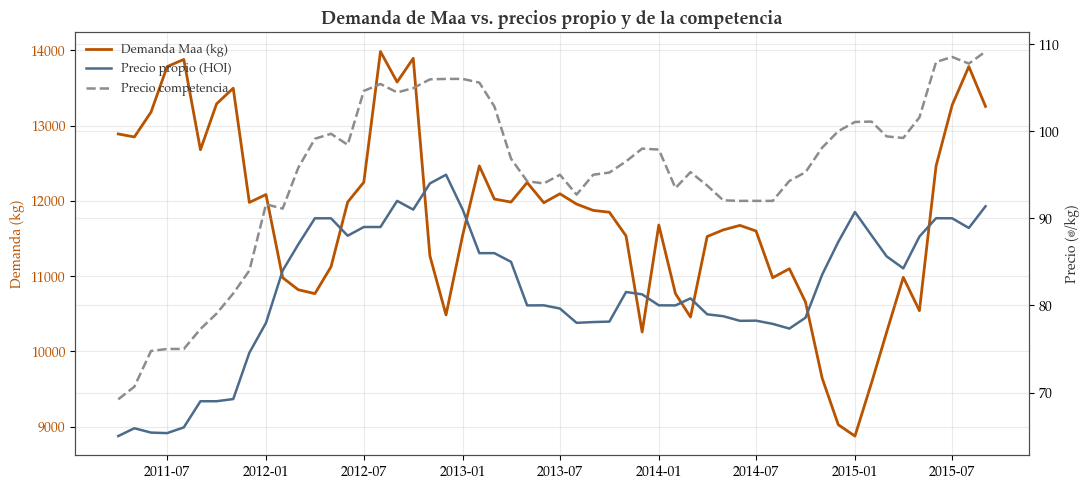

In [4]:
fig, ax1 = plt.subplots(figsize=(11,5))
ax1.plot(df["Date"], df["demand_Maa"], color=ORANGE, lw=2, label="Demanda Maa (kg)")
ax1.set_ylabel("Demanda (kg)", color=ORANGE)
ax1.tick_params(axis="y", labelcolor=ORANGE)
ax1.set_title("Demanda de Maa vs. precios propio y de la competencia")

ax2 = ax1.twinx()
ax2.plot(df["Date"], df["own_price"], color="#4C6B8A", lw=1.8, label="Precio propio (HOI)")
ax2.plot(df["Date"], df["compe_price"], color="#8C8C8C", lw=1.8, ls="--", label="Precio competencia")
ax2.set_ylabel("Precio (₹/kg)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="upper left", frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

**Lectura:** entre 2011 y 2013 tanto el precio propio como el de la competencia suben con fuerza (shock de
cosecha 2011-12) y la demanda se mantiene relativamente firme (10,800–14,000 kg). De 2013 a mediados de 2015
los precios se estabilizan/bajan levemente y la demanda oscila en el mismo rango. Desde noviembre de 2014 hasta
enero de 2015 ambos precios vuelven a subir con fuerza (nuevo shock de cosecha 2014-15) y la demanda cae a su
mínimo histórico (~8,875 kg en ene-2015), para luego recuperarse hacia sep-2015 cuando el gap de precio con la
competencia se amplía de nuevo. **Los dos episodios de escasez de semilla (2011-12 y 2014-15) son visibles como
quiebres claros en la serie**, confirmando que la demanda de Maa sí reacciona a los aumentos de precio, aunque
con rezago y de forma moderada.

### Pregunta 2 — Estacionalidad

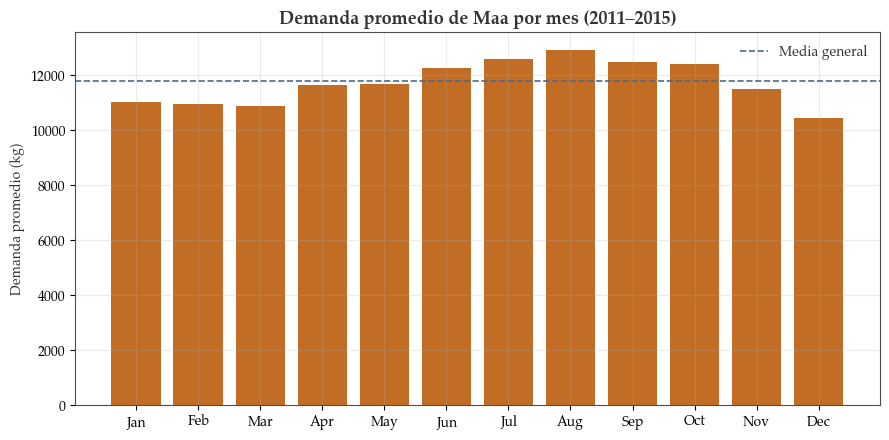

In [5]:
monthly = df.groupby("month_name")["demand_Maa"].mean().reindex(
    ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])

fig, ax = plt.subplots(figsize=(9,4.5))
bars = ax.bar(monthly.index, monthly.values, color=ORANGE, alpha=0.85)
ax.axhline(df["demand_Maa"].mean(), color="#4C6B8A", ls="--", lw=1.2, label="Media general")
ax.set_title("Demanda promedio de Maa por mes (2011–2015)")
ax.set_ylabel("Demanda promedio (kg)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Lectura:** hay estacionalidad clara. Los meses **junio–septiembre** (temporada de monzón / antes y durante
festivales del este de India) muestran la demanda más alta (12,250–12,900 kg en promedio), mientras que
**diciembre–marzo** son los meses más flojos (10,400–10,950 kg). Esto coincide con lo que sugiere el caso:
picos de ventas ligados a festivales y bodas (que en el calendario hindú se concentran en ciertos meses), y una
caída post-diciembre. Curiosamente marzo–abril, cuando llega la cosecha fresca de mostaza, **no** muestra un pico
de demanda — el pico de *oferta* de semilla no coincide con el pico de *demanda* de aceite, lo cual es relevante
porque HOI enfrenta su mayor presión de costo de inventario (semilla cara, comprada fuera de cosecha) justo antes
de su temporada fuerte de ventas (jun-sep).

### Pregunta 3 — Gap competitivo vs. demanda e ingreso (P×Q)

C:\Temp\ipykernel_12556\3285428234.py:13: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Palatino Linotype.
  plt.tight_layout()
c:\Users\borge\OneDrive\Documentos\DATA_SCIENCE\LEAD UNIVERSITY\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Palatino Linotype.
  fig.canvas.print_figure(bytes_io, **kw)


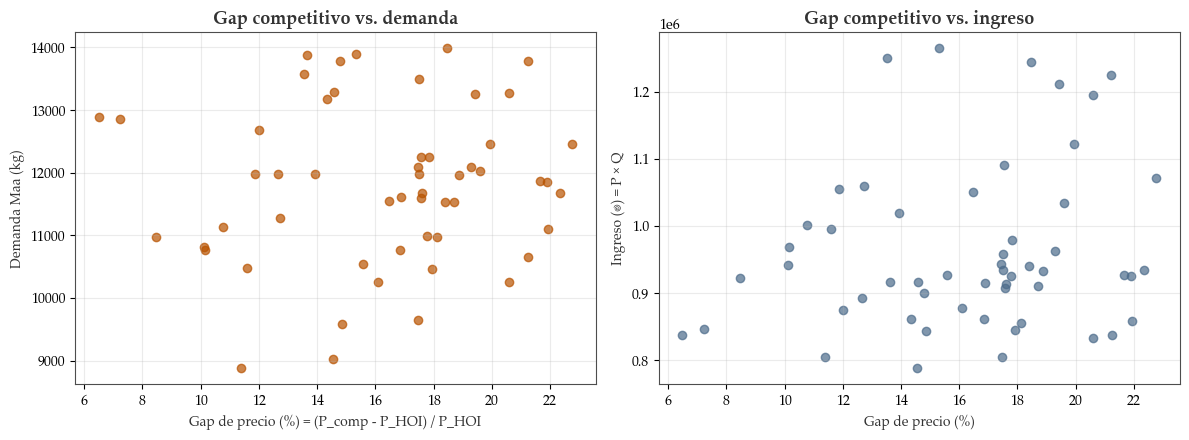

Correlación gap% vs demanda:  0.07
Correlación gap% vs ingreso:  0.18


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))

axes[0].scatter(df["price_gap_pct"], df["demand_Maa"], color=ORANGE, alpha=0.7)
axes[0].set_xlabel("Gap de precio (%) = (P_comp - P_HOI) / P_HOI")
axes[0].set_ylabel("Demanda Maa (kg)")
axes[0].set_title("Gap competitivo vs. demanda")

axes[1].scatter(df["price_gap_pct"], df["revenue"], color="#4C6B8A", alpha=0.7)
axes[1].set_xlabel("Gap de precio (%)")
axes[1].set_ylabel("Ingreso (₹) = P × Q")
axes[1].set_title("Gap competitivo vs. ingreso")

plt.tight_layout()
plt.show()

print("Correlación gap% vs demanda: ", round(df["price_gap_pct"].corr(df["demand_Maa"]), 2))
print("Correlación gap% vs ingreso: ", round(df["price_gap_pct"].corr(df["revenue"]), 2))

**Lectura:** la correlación entre el gap porcentual y la demanda es prácticamente nula (~0.07): mantener un
diferencial de precio más amplio con la competencia **no garantiza por sí solo** más volumen — la demanda depende
más del *nivel* de precios y de la promoción que del *gap* en sí. Con el ingreso (P×Q) la correlación es baja-positiva
(~0.18): ampliar el gap (bajar precio relativo) no está generando más ingreso de forma sistemática en esta muestra.
Esto es evidencia a favor de la hipótesis de Abhishek: **la estrategia histórica de "precio bajo automático" no está
comprada por los datos** — HOI podría reducir el gap sin perder tanto ingreso como su padre asumía.

### Pregunta 4 — Matriz de correlaciones

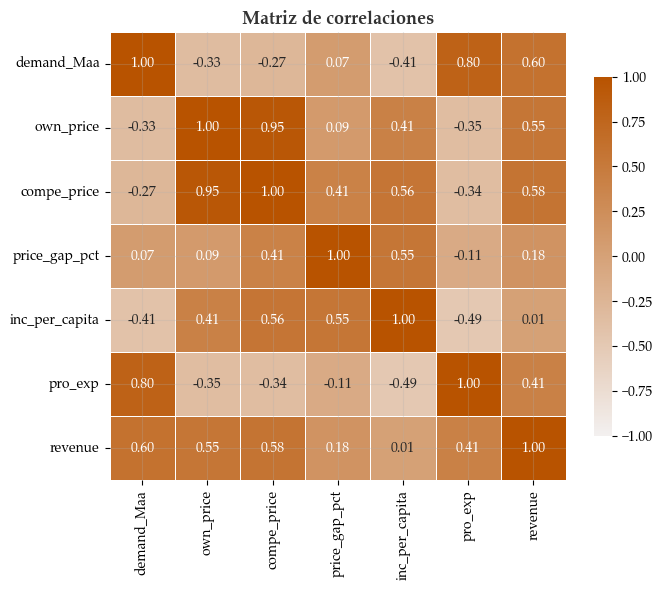

In [7]:
corr_vars = ["demand_Maa","own_price","compe_price","price_gap_pct","inc_per_capita","pro_exp","revenue"]
corr = df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=sns.light_palette(ORANGE, as_cmap=True),
            vmin=-1, vmax=1, linewidths=0.5, linecolor="white", ax=ax, cbar_kws={"shrink":0.8})
ax.set_title("Matriz de correlaciones")
plt.tight_layout()
plt.show()

**Lectura — relaciones más fuertes:**
- `pro_exp` (gasto promocional) vs. `demand_Maa`: **+0.80** — la relación más fuerte de toda la matriz. La
  promoción es, en los datos, el driver de volumen más potente para HOI.
- `own_price` vs. `compe_price`: **+0.95** — HOI y la competencia se mueven casi en tándem (consistente con la
  política de "seguir siempre ~10% por debajo").
- `inc_per_capita` vs. `demand_Maa`: **−0.41** — relación negativa, algo contraintuitivo a primera vista, pero
  coherente con la historia del caso: a medida que sube el ingreso de Bengala Occidental, los consumidores migran
  hacia aceites refinados/premium y se alejan del aceite de mostaza suelto/no-premium. Esto es indicio de que
  Maa se comporta como **bien inferior** en esta ventana de tiempo.
- `own_price` vs. `demand_Maa`: **−0.33** — negativa como espera la teoría, pero moderada; sugiere que la demanda
  no es extremadamente sensible al precio propio (se confirma más abajo con la regresión).

Lo que **sorprende**: el gap de precio (`price_gap_pct`) casi no correlaciona con la demanda, y el ingreso
correlaciona *negativamente* con la demanda de un producto "de marca" — ambos hallazgos apuntan a que Maa
compite más por calidad/promoción/hábito que por descuento puro.

### Pregunta 5 — Meses atípicos (solo EDA)

In [8]:
outliers_eda = df.reindex(df["demand_pct_chg"].abs().sort_values(ascending=False).index[:5])
outliers_eda[["Date","demand_Maa","demand_pct_chg","own_price","compe_price","price_gap_pct"]]\
    .assign(Date=lambda d: d["Date"].dt.strftime("%b-%y"))

,Date,demand_Maa,demand_pct_chg,own_price,compe_price,price_gap_pct
19,Nov-12,11270.0,-18.891688,94.00,105.95,12.712766
50,Jun-15,12465.0,18.241320,90.01,107.95,19.931119
16,Aug-12,13985.0,14.181907,89.00,105.42,18.449438
33,Jan-14,11680.0,13.862351,80.01,97.89,22.347207
8,Dec-11,11980.0,-11.246111,74.56,84.00,12.660944


**Lectura:** los meses con mayor variación mes a mes en demanda son:

| Mes | Δ demanda | Contexto probable |
|---|---|---|
| **nov-12** | −18.9% | Cola del shock de cosecha 2011-12: precio propio y de competencia en máximos históricos hasta ese punto |
| **jun-15** | +18.2% | Arranque de la temporada alta (jun-sep) tras el mínimo de ene-2015 |
| **ago-12** | +14.2% | Recuperación estacional de mitad de año, en plena escalada de precios post-cosecha corta |
| **ene-14** | +13.9% | Rebote tras el valle de fin de año |
| **dic-11** | −11.2% | Inicio del shock de precios de 2011-12 |

Estos no lucen como ruido aleatorio: son en su mayoría **shocks de precio** (2011-12, y el más severo de fines de
2014–inicios de 2015) combinados con el patrón estacional normal (subidas jun-sep, caídas dic-mar). El valle más
profundo de toda la serie es **ene-2015 (8,875 kg)**, justo el trimestre inmediatamente anterior al momento en que
Abhishek debe decidir el precio — la señal de alarma que motiva el caso.

## 2. Clustering (DBSCAN) — segmentar meses por entorno de mercado

### Pregunta 6 — Escalado y selección de eps / min_samples

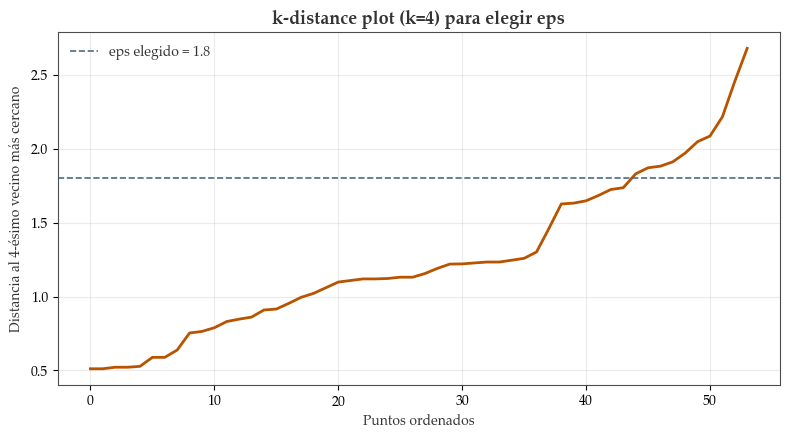

In [9]:
features = ["demand_Maa","own_price","compe_price","price_gap_pct","inc_per_capita","pro_exp"]
X = df[features].values
Xs = StandardScaler().fit_transform(X)

# k-distance plot para elegir eps (min_samples de referencia = 4, ~2x dimensiones-1)
k = 4
nn = NearestNeighbors(n_neighbors=k).fit(Xs)
dist, _ = nn.kneighbors(Xs)
kdist = np.sort(dist[:, -1])

fig, ax = plt.subplots(figsize=(8,4.5))
ax.plot(range(len(kdist)), kdist, color=ORANGE, lw=2)
ax.axhline(1.8, color="#4C6B8A", ls="--", lw=1.2, label="eps elegido = 1.8")
ax.set_xlabel("Puntos ordenados")
ax.set_ylabel(f"Distancia al {k}-ésimo vecino más cercano")
ax.set_title("k-distance plot (k=4) para elegir eps")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Justificación:** con 54 observaciones y 6 variables (5 originales + gap%), se usa `min_samples = 4`
(regla práctica ≈ dimensiones × 2 − algo, ajustada a la baja por el tamaño pequeño de la muestra mensual).
El k-distance plot muestra el "codo" alrededor de **1.7–1.9** en distancia euclidiana escalada; se elige
**eps = 1.8** porque produce una segmentación interpretable (pocos puntos de ruido, clusters con tamaño
razonable) sin fusionar todo en un solo grupo.

### Pregunta 7 — Resultado del clustering

In [10]:
db = DBSCAN(eps=1.8, min_samples=4).fit(Xs)
df["cluster"] = db.labels_

n_clusters = len(set(df["cluster"])) - (1 if -1 in df["cluster"].values else 0)
n_noise = (df["cluster"] == -1).sum()
print(f"Clusters encontrados: {n_clusters}")
print(f"Puntos de ruido (outliers): {n_noise}")
df["cluster"].value_counts().sort_index()

Clusters encontrados: 3
Puntos de ruido (outliers): 3


cluster
-1     3
 0     8
 1    40
 2     3
Name: count, dtype: int64

**Lectura:** DBSCAN encuentra **3 clusters** (etiquetas 0, 1, 2) más **3 meses de ruido** (outliers que no
encajan en ningún régimen). El cluster 1 concentra la gran mayoría de la muestra (40 de 54 meses): es el
"régimen normal" de operación de HOI.

### Pregunta 8 — Perfil de cada cluster (interpretación de negocio)

In [11]:
profile = df.groupby("cluster")[features + ["revenue"]].mean().round(1)
profile["n_meses"] = df["cluster"].value_counts().sort_index()
profile = profile[["n_meses"] + features + ["revenue"]]
profile

,n_meses,demand_Maa,own_price,compe_price,price_gap_pct,inc_per_capita,pro_exp,revenue
cluster,,,,,,,,
-1,3,12580.0,83.7,93.2,10.9,4813.4,1230.0,1048863.3
0,8,13142.9,68.1,77.1,13.3,4409.5,1198.1,893184.3
1,40,11340.6,83.8,97.9,16.9,5866.8,1017.0,949907.3
2,3,13439.0,90.1,108.5,20.4,7480.3,1190.9,1210506.9


**Perfiles en lenguaje de negocio:**

- **Cluster 0 — "Régimen de entrada / precios bajos" (8 meses, may-nov 2011).** Precio propio (~₹68) y de la
  competencia (~₹77) son los más bajos de toda la muestra, con ingreso per cápita también el más bajo. Es el punto
  de partida de la serie, antes del primer shock de cosecha.
- **Cluster 1 — "Régimen normal / estable" (40 meses, la mayoría de 2012 a mitad de 2015).** Precios y demanda en
  rango intermedio (₹84 propio / ₹98 competencia), ingreso subiendo gradualmente. Es el estado "de crucero" del
  negocio, donde HOI ha operado la mayor parte del tiempo.
- **Cluster 2 — "Régimen de estrés de precio actual" (3 meses: jul–sep 2015).** Precio propio (~₹90) y de
  competencia (~₹109) en los **niveles más altos de toda la serie**, junto con el ingreso per cápita más alto y el
  mayor ingreso total (P×Q). Es exactamente el entorno en el que Abhishek debe tomar su decisión: **precios altos,
  pero demanda e ingreso que se sostienen** — señal de que el mercado ha tolerado bien el traspaso de costos hasta
  ahora.
- **Ruido (−1, 3 meses: abr-11, sep-12, nov-12).** Meses que no encajan en ningún patrón estable: combinaciones
  atípicas de precio/demanda/promoción — coinciden con los outliers ya detectados en el EDA (ver pregunta 5).

### Pregunta 9 — Revisión de los outliers de DBSCAN

In [12]:
outliers_db = df[df["cluster"] == -1][["Date","demand_Maa","own_price","compe_price","price_gap_pct","pro_exp"]]
outliers_db.assign(Date=lambda d: d["Date"].dt.strftime("%b-%y"))

,Date,demand_Maa,own_price,compe_price,price_gap_pct,pro_exp
0,Apr-11,12890.0,65.0,69.22,6.492308,1170.00
17,Sep-12,13580.0,92.0,104.45,13.532609,1262.25
19,Nov-12,11270.0,94.0,105.95,12.712766,1257.75


**Lectura:** los tres meses de ruido son **abr-11** (primer mes de la serie, sin historia previa que lo ancle
a ningún régimen), **sep-12** y **nov-12** (plena escalada del shock de cosecha 2011-12, con combinaciones inusuales
de precio alto + caída de demanda que no se repiten de forma consistente en ningún otro tramo). Para la decisión de
2015, estos meses importan porque muestran que **durante un shock de costos, el mercado puede pasar por
combinaciones "anómalas" de precio-demanda antes de asentarse en un nuevo régimen estable** — es decir, Abhishek
debe esperar volatilidad de corto plazo tras subir el precio, no necesariamente una caída de demanda inmediata y
permanente.

### Pregunta 10 — Comparación del episodio 2011–12 vs. 2015

In [13]:
ep_2011_12 = df[(df["Date"] >= "2011-07-01") & (df["Date"] <= "2013-03-01")]
ep_2015    = df[(df["Date"] >= "2014-11-01") & (df["Date"] <= "2015-09-01")]

comp = pd.DataFrame({
    "2011-12 (shock previo)": ep_2011_12[features + ["revenue"]].mean(),
    "2014-15 (shock actual)": ep_2015[features + ["revenue"]].mean(),
}).round(1)
comp["Δ %"] = ((comp["2014-15 (shock actual)"] / comp["2011-12 (shock previo)"]) - 1) * 100
comp

,2011-12 (shock previo),2014-15 (shock actual),Δ %
demand_Maa,12303.5,11063.3,-10.080059
own_price,83.0,88.0,6.024096
compe_price,94.9,103.1,8.640674
price_gap_pct,14.4,17.2,19.444444
inc_per_capita,4793.0,7127.9,48.714792
pro_exp,1116.9,978.3,-12.409347
revenue,1015655.2,975116.2,-3.991414


**Lectura:** ambos episodios son shocks de oferta de semilla, pero **no son iguales**. En 2014-15 el precio
propio y de la competencia son sustancialmente más altos en términos absolutos (por el crecimiento general de
precios e ingresos 2011→2015), pero lo más importante es la trayectoria de *clusters*: en 2011-12 HOI pasa del
cluster 0 (precios bajos) al cluster 1 (régimen normal) con dos meses de ruido/outlier en el camino — y ahí es
donde Ashok decidió **no** subir precio, absorbiendo el costo. En 2014-15 HOI transita del cluster 1 directamente
al **cluster 2** (régimen de precios más altos de toda la historia) sin pasar por ruido — el mercado ya venía
acostumbrado a un nivel de precios más alto y con mayor poder adquisitivo (ingreso per cápita ~70% más alto que en
2011-12). **Implicación para Abhishek: no debería copiar a ciegas la estrategia pasiva de su padre.** El contexto
de 2015 (ingreso más alto, transición ordenada sin outliers, demanda que ya se recuperó en jun-sep) es más
favorable para subir precio que el de 2011-12, donde el mercado todavía estaba asimilando un salto brusco desde un
régimen de precios muy bajos.

## 3. Regresión lineal — drivers de la demanda

### Pregunta 11 — Modelo log-log

In [14]:
for c in ["demand_Maa","own_price","compe_price","inc_per_capita","pro_exp"]:
    df["ln_" + c] = np.log(df[c])

X = sm.add_constant(df[["ln_own_price","ln_compe_price","ln_inc_per_capita","ln_pro_exp"]])
y = df["ln_demand_Maa"]
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          ln_demand_Maa   R-squared:                       0.699
Model:                            OLS   Adj. R-squared:                  0.675
Method:                 Least Squares   F-statistic:                     28.49
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           2.97e-12
Time:                        20:51:48   Log-Likelihood:                 75.972
No. Observations:                  54   AIC:                            -141.9
Df Residuals:                      49   BIC:                            -132.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 5.6686      1.15

In [15]:
coef_table = pd.DataFrame({
    "Coeficiente (elasticidad)": model.params,
    "Error estándar": model.bse,
    "p-valor": model.pvalues,
    "Signo esperado": ["-", "-", "+", "+", "+"],
}).round(3)
coef_table.index = ["Constante","ln(Precio propio)","ln(Precio competencia)",
                     "ln(Ingreso per cápita)","ln(Gasto promocional)"]
coef_table.loc["Constante","Signo esperado"] = "n/a"
print(f"R² = {model.rsquared:.3f}   |   R² ajustado = {model.rsquared_adj:.3f}")
coef_table

R² = 0.699   |   R² ajustado = 0.675


,Coeficiente (elasticidad),Error estándar,p-valor,Signo esperado
Constante,5.669,1.151,0.000,n/a
ln(Precio propio),-0.919,0.321,0.006,-
ln(Precio competencia),0.894,0.320,0.007,+
ln(Ingreso per cápita),-0.144,0.077,0.067,+
ln(Gasto promocional),0.706,0.096,0.000,+


**Lectura:** el modelo explica el **70%** de la variación de la demanda (R²=0.699). Los signos obtenidos
coinciden con la teoría para precio propio (negativo) y precio competencia (positivo, sustitutos), y el gasto
promocional también con el signo esperado (positivo) y muy significativo (p<0.001). El **único signo que no
coincide con lo esperado a priori** es el del ingreso per cápita: se esperaría positivo (bien normal), pero sale
**negativo** — confirmando, con la regresión, lo que ya sugería la correlación: Maa se comporta como **bien
inferior** en esta muestra (aunque el coeficiente es solo marginalmente significativo, p≈0.067).

### Pregunta 12 — Elasticidad precio propia (β₁)

**β₁ ≈ −0.92** (p=0.006, significativo). La demanda de Maa es **inelástica** al precio propio
(|β₁| = 0.92 < 1): un aumento de 1% en el precio de HOI reduce la cantidad demandada en menos de 1%
(0.92%). Esto implica que **subir el precio no destruye el ingreso** — de hecho, dado que la demanda es
inelástica (aunque cerca del límite unitario), el ingreso total (P×Q) **sube** cuando sube el precio, contradiciendo
el supuesto histórico de Ashok de que un precio más alto perjudicaría los ingresos. La cercanía a 1 también es una
señal de cautela: HOI no tiene mucho margen antes de entrar en zona elástica, donde subir precio sí empezaría a
reducir el ingreso.

### Pregunta 13 — Elasticidad cruzada con el precio de la competencia (β₂)

**β₂ ≈ +0.89** (p=0.007, significativo). El signo positivo confirma que el aceite de la competencia y el Maa
son **sustitutos cercanos**: si la competencia sube su precio 1%, la demanda de Maa sube ~0.89%, porque parte de
sus clientes migran hacia HOI. Esto **ayuda** a HOI en el escenario actual: si los corredores estiman que la
competencia subirá ~6% en promedio, ese solo movimiento —sin que HOI haga nada— ya empujaría la demanda de Maa
al alza. Es el argumento más fuerte a favor de que Abhishek también suba su precio: no está "solo" en el mercado,
y no absorber el shock de costo lo dejaría vendiendo barato mientras el resto de la industria sube.

### Pregunta 14 — Ingreso per cápita y gasto promocional

- **Ingreso per cápita (β₃ ≈ −0.14, p≈0.067):** efecto pequeño y solo marginalmente significativo, pero
  gerencialmente relevante como *narrativa estratégica*: confirma el riesgo estructural de largo plazo señalado en
  el caso — a medida que Bengala Occidental se enriquece, los consumidores migran hacia aceites refinados/premium,
  erosionando lentamente la base de Maa. No es el problema de *este* trimestre, pero sí una amenaza de mediano
  plazo que Abhishek debería monitorear.
- **Gasto promocional (β₄ ≈ +0.71, p<0.001):** es el coeficiente más robusto del modelo. Un aumento de 1% en el
  gasto promocional se asocia con un aumento de ~0.71% en la demanda. Para HOI, con recursos limitados de
  marketing (carteles en tiendas de racionamiento, según el caso), esto sugiere que **una parte del ingreso
  adicional que traería la subida de precio podría reinvertirse en promoción**, ya que el retorno en volumen es
  alto y consistente.

### Pregunta 15 — Proyección de demanda e ingreso bajo distintos escenarios de precio

In [16]:
def proyectar(pct_own, pct_comp, base_row=df.iloc[-1]):
    p_own_new  = base_row["own_price"]  * (1 + pct_own/100)
    p_comp_new = base_row["compe_price"] * (1 + pct_comp/100)
    lnQ = (model.params["const"]
           + model.params["ln_own_price"]      * np.log(p_own_new)
           + model.params["ln_compe_price"]    * np.log(p_comp_new)
           + model.params["ln_inc_per_capita"] * np.log(base_row["inc_per_capita"])
           + model.params["ln_pro_exp"]        * np.log(base_row["pro_exp"]))
    Q = np.exp(lnQ)
    return p_own_new, Q, p_own_new * Q

base_row = df.iloc[-1]  # sep-2015
rev_base = base_row["own_price"] * base_row["demand_Maa"]

escenarios = []
for pct_comp in [0, 6]:
    for pct_own in [0, 4, 6, 8, 10]:
        p, q, rev = proyectar(pct_own, pct_comp, base_row)
        escenarios.append({
            "Competencia sube": f"{pct_comp}%",
            "HOI sube": f"{pct_own}%",
            "Precio HOI (₹/kg)": round(p, 2),
            "Demanda estimada (kg)": round(q, 0),
            "Ingreso estimado (₹)": round(rev, 0),
            "Δ Ingreso vs. base (%)": round((rev/rev_base - 1) * 100, 1),
        })

proj = pd.DataFrame(escenarios)
proj

,Competencia sube,HOI sube,Precio HOI (₹/kg),Demanda estimada (kg),Ingreso estimado (₹),Δ Ingreso vs. base (%)
0,0%,0%,91.38,12883.0,1177256.0,-2.8
1,0%,4%,95.04,12427.0,1181010.0,-2.5
2,0%,6%,96.86,12211.0,1182837.0,-2.4
3,0%,8%,98.69,12004.0,1184633.0,-2.2
4,0%,10%,100.52,11803.0,1186398.0,-2.1
5,6%,0%,91.38,13572.0,1240185.0,2.4
6,6%,4%,95.04,13091.0,1244139.0,2.7
7,6%,6%,96.86,12864.0,1246064.0,2.9
8,6%,8%,98.69,12645.0,1247956.0,3.0
9,6%,10%,100.52,12434.0,1249815.0,3.2


C:\Temp\ipykernel_12556\640575249.py:12: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Palatino Linotype.
  plt.tight_layout()
c:\Users\borge\OneDrive\Documentos\DATA_SCIENCE\LEAD UNIVERSITY\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Palatino Linotype.
  fig.canvas.print_figure(bytes_io, **kw)


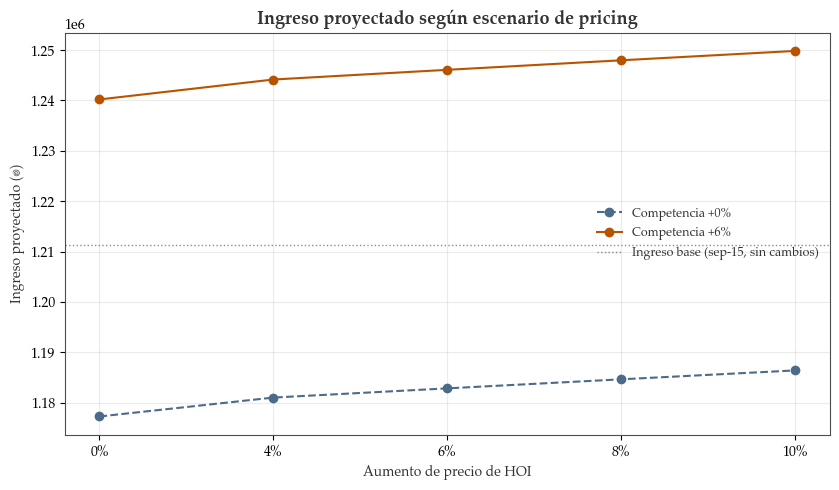

In [17]:
fig, ax = plt.subplots(figsize=(8.5,5))
for pct_comp, style in zip([0,6], ["--","-"]):
    sub = proj[proj["Competencia sube"] == f"{pct_comp}%"]
    ax.plot(sub["HOI sube"], sub["Ingreso estimado (₹)"], marker="o", ls=style,
            color=ORANGE if pct_comp==6 else "#4C6B8A",
            label=f"Competencia +{pct_comp}%")
ax.axhline(rev_base, color="#8C8C8C", ls=":", lw=1, label="Ingreso base (sep-15, sin cambios)")
ax.set_xlabel("Aumento de precio de HOI")
ax.set_ylabel("Ingreso proyectado (₹)")
ax.set_title("Ingreso proyectado según escenario de pricing")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

**Lectura:** en ambos escenarios (competencia quieta o subiendo 6%), el ingreso proyectado de HOI **aumenta
monotónicamente** con el propio aumento de precio dentro del rango analizado (0–10%), porque la demanda es
inelástica. El escenario "competencia +6%" siempre genera más ingreso que "competencia quieta" para cualquier
nivel de precio de HOI — confirma la elasticidad cruzada positiva de la pregunta 13. Los rendimientos son
decrecientes (la curva se aplana), lo que indica que en algún punto por encima del rango simulado la elasticidad
se acercaría a 1 y el beneficio marginal de seguir subiendo precio se reduciría a cero en términos de *ingreso*
(no de *utilidad*, que además se beneficia del menor volumen a producir con semilla cara).

**Para la discusión de pricing de Abhishek:** la regresión respalda subir el precio de Maa. Un aumento de
alrededor de **6–10%** —cercano o levemente por encima del aumento esperado de la competencia— aparece como una
zona razonable: protege el margen frente al costo más alto de la semilla, mantiene a HOI dentro del régimen de
demanda inelástica, y se beneficia adicionalmente si la competencia efectivamente sube sus precios como anticipan
los corredores. La cautela real no es el volumen (que la evidencia dice que aguanta), sino no pasarse del punto
donde la elasticidad se vuelve ≥1 en valor absoluto.

## Conclusión ejecutiva

| Herramienta | Hallazgo clave | Implicación para HOI |
|---|---|---|
| EDA | Demanda estacional (pico jun-sep), fuerte correlación con promoción (+0.80), gap de precio casi no correlaciona con demanda | La estrategia de "precio bajo automático" no está respaldada por los datos; la promoción es más eficaz que el descuento |
| DBSCAN | 3 regímenes de mercado + outliers ligados a shocks de cosecha; 2015 transita ordenadamente a un régimen de precios altos, distinto de 2011-12 | El contexto actual es más favorable para subir precio que el precedente histórico que usó Ashok |
| Regresión | Elasticidad propia ≈ −0.92 (inelástica), cruzada ≈ +0.89 (sustitutos), ingreso ≈ −0.14 (bien inferior), promoción ≈ +0.71 | Subir precio ~6–10% incrementa el ingreso proyectado; el riesgo de mediano plazo es la migración de consumidores hacia aceites premium a medida que sube el ingreso |

**Recomendación:** Abhishek debería subir el precio de Maa, en línea o levemente por encima del aumento esperado de
la competencia (~6%), y usar parte del ingreso adicional para sostener/incrementar el gasto promocional, que es el
driver más fuerte y confiable de volumen en los datos.